# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

Hello


# Loading Data

In [5]:
wc_df = pd.read_csv("ANALYSIS Task1/CWC23_all_innings.csv")
print("DataFrame Shape: ", wc_df.shape)
wc_df.head()

DataFrame Shape:  (1408, 20)


,team,player,bat_or_bowl,bb_bf,runs,wkts,wicketball_prob,runs_per_ball,opposition,ground,start_date,overs,mdns,econ,inns,4s,6s,sr,not_out,mins
0,PAK,Shaheen Shah Afridi (PAK),bowl,60,45,3.0,0.05,0.750000,v South Africa,Chennai,27-Oct-23,10.0,0.0,4.5,2,NaN,NaN,NaN,NaN,NaN
1,ENG,DJ Willey (ENG),bowl,60,45,3.0,0.05,0.750000,v India,Lucknow,29-Oct-23,10.0,2.0,4.5,1,NaN,NaN,NaN,NaN,NaN
2,NZ,MJ Henry (NZ),bowl,60,48,3.0,0.05,0.800000,v England,Ahmedabad,5-Oct-23,10.0,1.0,4.8,1,NaN,NaN,NaN,NaN,NaN
3,NZ,LH Ferguson (NZ),bowl,60,49,3.0,0.05,0.816667,v Bangladesh,Chennai,13-Oct-23,10.0,0.0,4.9,1,NaN,NaN,NaN,NaN,NaN
4,AFG,Noor Ahmad (AFG),bowl,60,49,3.0,0.05,0.816667,v Pakistan,Chennai,23-Oct-23,10.0,0.0,4.9,1,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

In [7]:
# Checking information about the Dataset
wc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1408 entries, 0 to 1407
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team             1408 non-null   object 
 1   player           1408 non-null   object 
 2   bat_or_bowl      1408 non-null   object 
 3   bb_bf            1408 non-null   int64  
 4   runs             1408 non-null   int64  
 5   wkts             562 non-null    float64
 6   wicketball_prob  1408 non-null   float64
 7   runs_per_ball    1408 non-null   float64
 8   opposition       1408 non-null   object 
 9   ground           1408 non-null   object 
 10  start_date       1408 non-null   object 
 11  overs            562 non-null    float64
 12  mdns             562 non-null    float64
 13  econ             562 non-null    float64
 14  inns             1408 non-null   int64  
 15  4s               846 non-null    float64
 16  6s               846 non-null    float64
 17  sr            

In [8]:
# Determining the number of unique values in each column
wc_df.nunique()

team                10
player             152
bat_or_bowl          2
bb_bf              117
runs               128
wkts                 7
wicketball_prob    129
runs_per_ball      645
opposition          10
ground              10
start_date          41
overs               38
mdns                 4
econ               230
inns                 2
4s                  20
6s                  12
sr                 429
not_out              2
mins               156
dtype: int64

From the above information, we can see that there exist a total of 10 teams and 152 players.

In [10]:
# Handling Missing Data
(wc_df.isnull().sum() / len(wc_df)) * 100

team                0.000000
player              0.000000
bat_or_bowl         0.000000
bb_bf               0.000000
runs                0.000000
wkts               60.085227
wicketball_prob     0.000000
runs_per_ball       0.000000
opposition          0.000000
ground              0.000000
start_date          0.000000
overs              60.085227
mdns               60.085227
econ               60.085227
inns                0.000000
4s                 39.914773
6s                 39.914773
sr                 39.914773
not_out            39.914773
mins               39.914773
dtype: float64

The above information shows the rate of null values for each column. In visualizing the dataset with null values, we can obtain the following below:

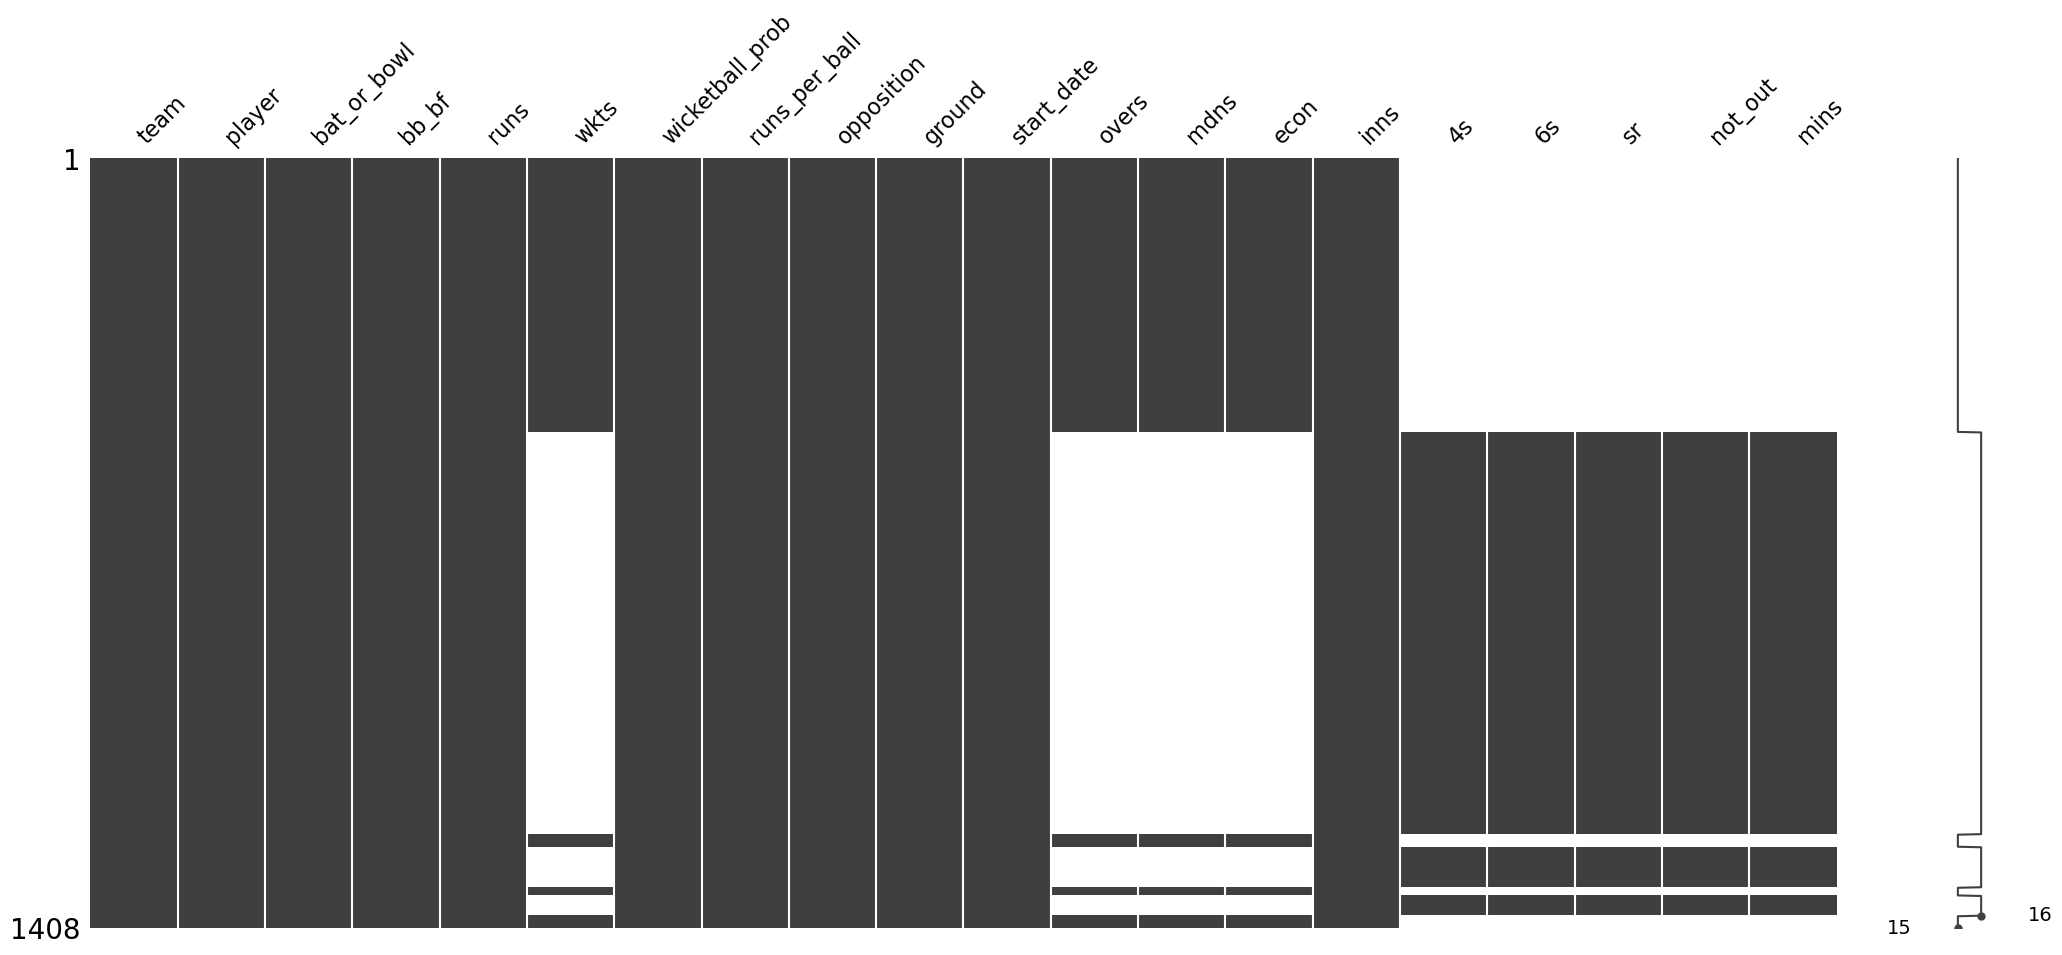

In [12]:
msno.matrix(wc_df);

In order to fully handle this missing values, we are going to fill it with the constant value "0".

In [14]:
wc_df.fillna(0, inplace = True)

In [15]:
# Dealing with Duplicates
# Identifying duplicates
duplicates = wc_df[wc_df.duplicated(keep = False)]
print("Number of Duplicates Before:", duplicates.duplicated().sum())

Number of Duplicates Before: 2


In [16]:
# Removing duplicates
drop_duplicates = wc_df.drop_duplicates(inplace = True)
print("Number of Duplicates After:", wc_df.duplicated().sum())

Number of Duplicates After: 0


In [17]:
print("New Data shape:", wc_df.shape)

New Data shape: (1406, 20)


In [18]:
# Correcting Errors
# "Opposition" features
wc_df["opposition"] = wc_df["opposition"].str[2:]

In [19]:
# Data Transformation
wc_df["start_date"] = pd.to_datetime(wc_df["start_date"], format = "%d-%b-%y")  # converting datatype from 'object' to 'datetime'

print("start_date datatype:", wc_df["start_date"].dtypes)

start_date datatype: datetime64[ns]


# Exploratory Data Analysis - EDA

Below is a **statistical summary** of the data. 

In [22]:
# Statistical Summary
wc_df.drop(columns = ["start_date"]).describe()

,bb_bf,runs,wkts,wicketball_prob,runs_per_ball,overs,mdns,econ,inns,4s,6s,sr,not_out,mins
count,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000,1406.000000
mean,35.353485,33.284495,0.481508,0.069607,0.900034,2.934922,0.102418,2.376963,1.470839,1.567568,0.452347,50.372859,0.091038,25.703414
std,25.234407,28.048233,0.960063,0.150176,0.470163,3.976489,0.359172,3.212831,0.499327,2.753850,1.223235,57.766236,0.287766,38.437668
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,11.000000,0.000000,0.010667,0.625000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,32.000000,29.000000,0.000000,0.032258,0.879655,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,38.880000,0.000000,8.000000
75%,54.000000,49.000000,1.000000,0.062181,1.131657,7.000000,0.000000,5.135000,2.000000,2.000000,0.000000,89.160000,0.000000,36.000000
max,143.000000,201.000000,7.000000,1.000000,6.000000,10.000000,3.000000,16.000000,2.000000,21.000000,11.000000,600.000000,1.000000,217.000000


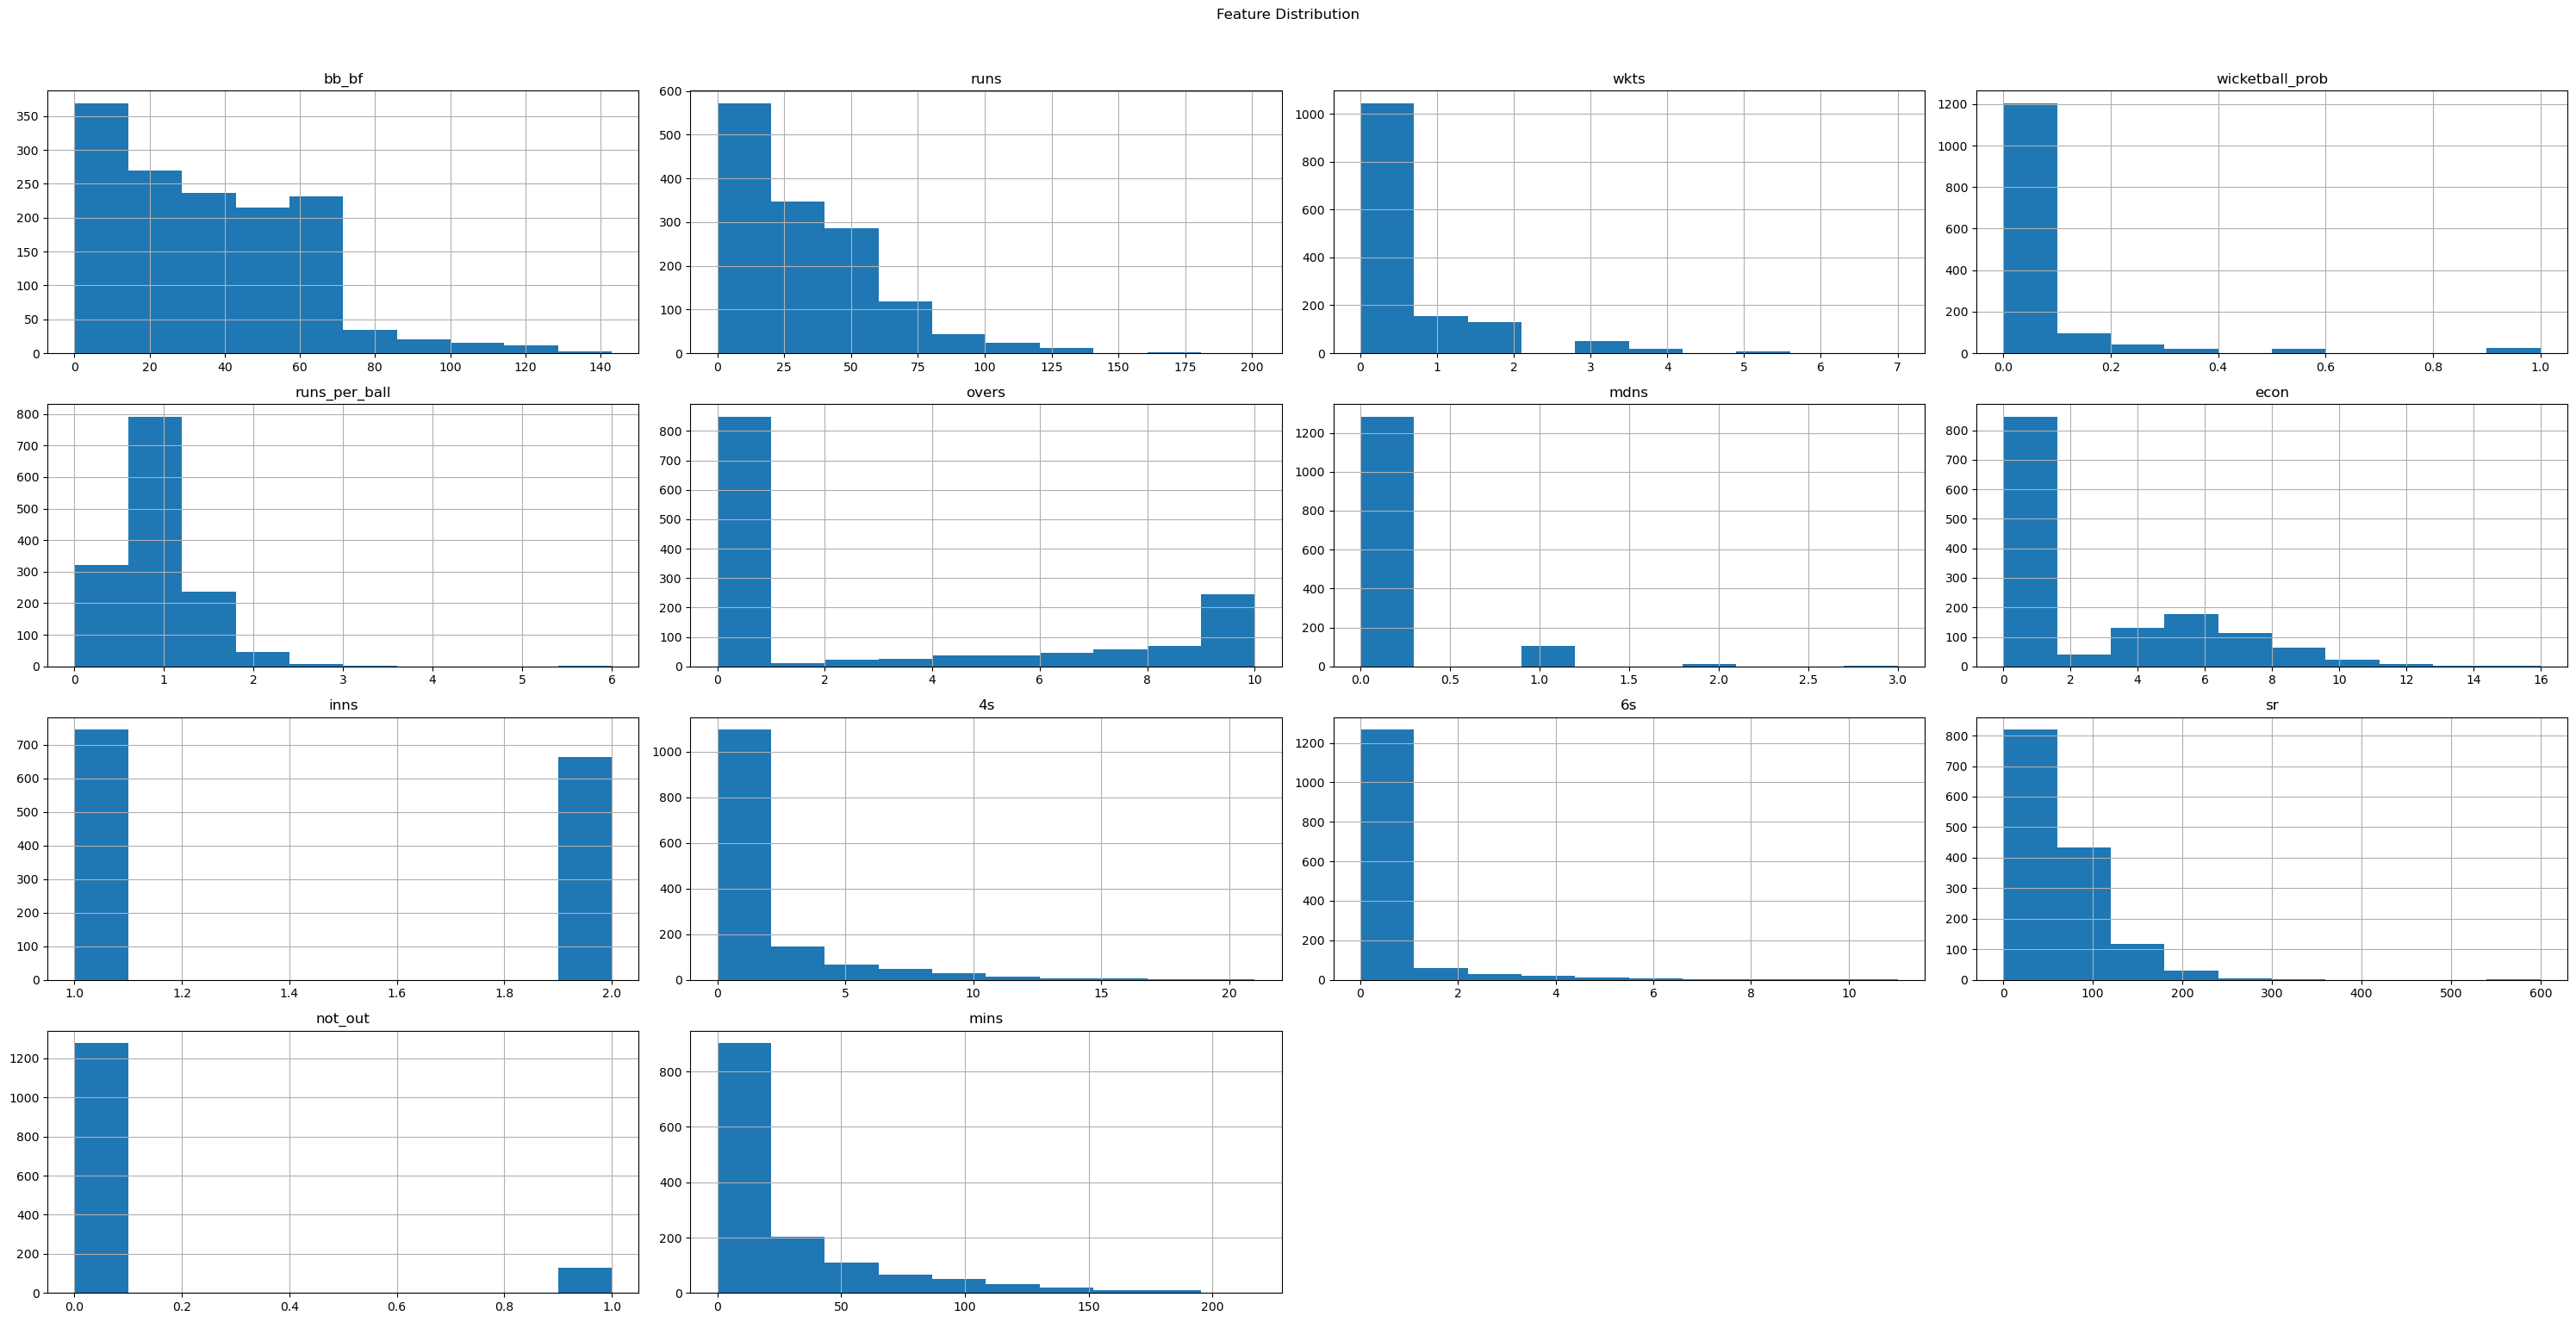

In [23]:
# Data Visualization
wc_df.drop(columns = ["start_date"]).hist(figsize = (30, 15))
plt.suptitle('Feature Distribution', x = 0.5, y = 1.02, ha = 'center', fontsize = 'large')
plt.tight_layout()
plt.show()

The distribution of most features of the dataset are skewed to the left. 

### Tasks to Perform

#### 1. Team Performance Analysis

In order to determine the performance of each team during the tournament, we will likely focus on the *team's batting performance* and *team's bowling performance*.

******************************
**Batting Metrics** - This metrics focuses on the team's overall scoring and efficiency

In [28]:
# Retrieving only batting players
bat_df = wc_df[wc_df["bat_or_bowl"] == "bat"].copy()

In [29]:
def batting_metrics(bat_df):
    """
    Analyzes team performance by grouping data and calculating summary metrics.
    """
    # Group the DataFrame by 'team' and calculate aggregate statistics.
    team_performance = bat_df.groupby('team').agg(
        total_runs = ('runs', 'sum'),  # Total runs of each team
        average_runs = ('runs', 'mean'),  # A team's scoring capability
        total_4s = ('4s', 'sum'), # Power-hitting ability
        total_6s = ('6s', 'sum'), # Power-hitting ability 
        total_balls_faced = ('bb_bf', 'sum')
    ).reset_index()
    
    # Calculate additional metrics after aggregation
    team_performance['boundary_percentage (%)'] = (((team_performance['total_4s'] * 4) + (team_performance['total_6s'] * 6)) / team_performance['total_runs']) * 100   # Percentage of a team's total runs that came from boundaries. 
    team_performance['strike_rate (%)'] = (team_performance['total_runs'] / team_performance['total_balls_faced']) * 100   # Measures how quickly a team scores runs
    
    return team_performance

if __name__ == '__main__':
    print("-" * 100)
    
    # Analyze and summarize team-wise performance.
    team_summary_bat = batting_metrics(bat_df)
    print("Team's Batting Performance Summary:")
team_summary_bat

----------------------------------------------------------------------------------------------------
Team's Batting Performance Summary:


,team,total_runs,average_runs,total_4s,total_6s,total_balls_faced,boundary_percentage (%),strike_rate (%)
0,AFG,1990,26.891892,178.0,42.0,2392,48.442211,83.193980
1,AUS,2722,29.268817,265.0,92.0,2787,59.221161,97.667743
2,BAN,1944,21.842697,188.0,43.0,2459,51.954733,79.056527
3,ENG,2135,22.010309,216.0,51.0,2276,54.800937,93.804921
4,IND,2810,42.575758,265.0,89.0,2685,56.725979,104.655493
5,NED,1728,17.632653,163.0,33.0,2300,49.189815,75.130435
6,NZ,2712,33.481481,265.0,82.0,2616,57.227139,103.669725
7,PAK,2220,29.600000,220.0,60.0,2307,55.855856,96.228869
8,SA,2773,31.873563,243.0,99.0,2787,56.473134,99.497668
9,SL,1942,23.119048,201.0,45.0,2257,55.303811,86.043420


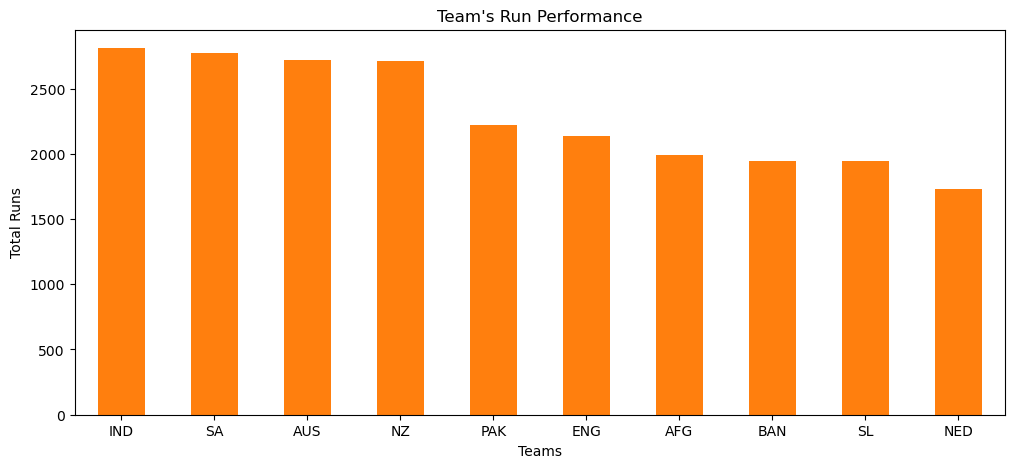

In [30]:
# Creating a Bar chart to visualize the runs score of the teams
team_summary_bat.groupby('team')['total_runs'].sum().sort_values(ascending = False).plot(kind = 'bar', figsize = [12, 5], color = "C1")
plt.xlabel('Teams')
plt.ylabel('Total Runs')
plt.title("Team's Run Performance")
plt.xticks(rotation = 0)
plt.show()

*From the above chart, we can observe that "IND" scored the highest runs during the tournament. Second by "SA" and third by "AUS".*

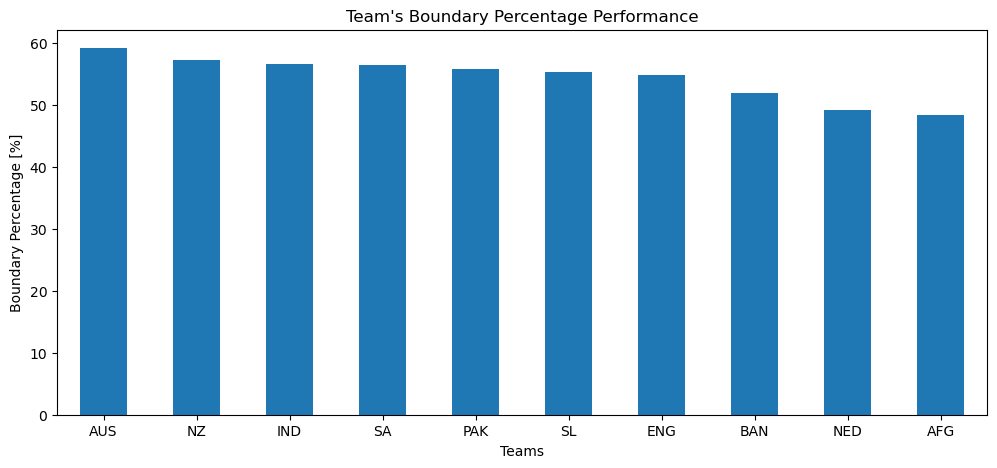

In [32]:
# Visualizing the boundary percentage of each team
team_summary_bat.groupby('team')['boundary_percentage (%)'].sum().sort_values(ascending = False).plot(kind = 'bar', figsize = [12, 5])
plt.xlabel('Teams')
plt.ylabel('Boundary Percentage [%]')
plt.title("Team's Boundary Percentage Performance")
plt.xticks(rotation = 0)
plt.show()

************************
**Bowling Metrics** - This metrics focuses on how a team restricts the opposition and takes wickets.

In [34]:
# Retrieving only bowling players
bowl_df = wc_df[wc_df["bat_or_bowl"] == "bowl"].copy()

In [35]:
def bowling_metrics(bowl_df):
    """
    Analyzes team performance by grouping data and calculating summary metrics.
    """
    # Group the DataFrame by 'team' and calculate aggregate statistics.
    team_performance = bowl_df.groupby('team').agg(
        total_runs = ('runs', 'sum'),  # Total runs of each team
        total_wickets = ('wkts', 'sum'),  # A team's ability to dismiss the opposition and prevent them from scoring
        total_balls_bowled = ('bb_bf', 'sum'),   # bb - balls bowled
        total_econ = ('econ', 'sum'), # Measures how many runs the opposing team gives away per over
        avg_econ = ('econ', 'mean'), 
        total_maidens = ('mdns', 'sum')   # Demonstrates a team's control and accuracy
    ).reset_index()
    
    # Calculate additional metrics after aggregation
    team_performance['bowling_avg'] = team_performance['total_econ'] / team_performance['total_wickets']   # A strong indicator of an effective and stable bowling attack.
    team_performance['bowling_strike_rate'] = team_performance['total_balls_bowled'] / team_performance['total_wickets']  # Measures how many balls a team needs to bowl to take a single wicket
    
    return team_performance

if __name__ == '__main__':
    print("-" * 100)
    
    # Analyze and summarize team-wise performance.
    team_summary_bowl = bowling_metrics(bowl_df)
    print("Team's Bowling Performance Summary:")
team_summary_bowl

----------------------------------------------------------------------------------------------------
Team's Bowling Performance Summary:


,team,total_runs,total_wickets,total_balls_bowled,total_econ,avg_econ,total_maidens,bowling_avg,bowling_strike_rate
0,AFG,2144,53.0,2403,317.01,5.763818,13.0,5.981321,45.339623
1,AUS,2512,77.0,2695,350.99,5.661129,13.0,4.558312,35.000000
2,BAN,2414,51.0,2390,316.98,6.095769,13.0,6.215294,46.862745
3,ENG,2261,65.0,2343,321.62,6.068302,14.0,4.948000,36.046154
4,IND,1973,94.0,2506,287.90,4.963793,23.0,3.062766,26.659574
5,NED,2540,63.0,2502,364.05,6.170339,11.0,5.778571,39.714286
6,NZ,2664,71.0,2704,392.94,6.237143,17.0,5.534366,38.084507
7,PAK,2566,65.0,2478,326.92,6.286923,8.0,5.029538,38.123077
8,SA,2324,88.0,2561,306.87,5.682778,20.0,3.487159,29.102273
9,SL,2424,50.0,2259,356.73,6.606111,12.0,7.134600,45.180000


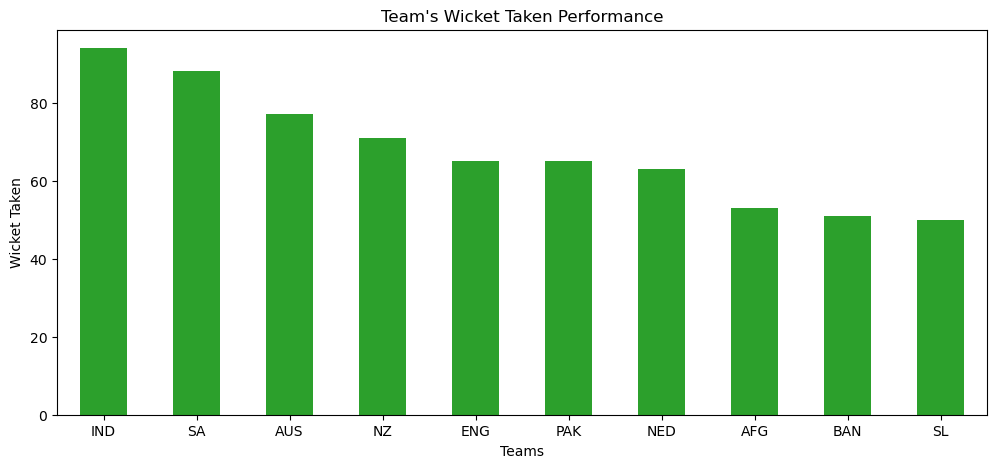

In [36]:
# Visualizing a bar chart to represent the number of wicket taken for each team
team_summary_bowl.groupby('team')['total_wickets'].sum().sort_values(ascending = False).plot(kind = 'bar', figsize = [12, 5], color = "C2")
plt.xlabel('Teams')
plt.ylabel('Wicket Taken')
plt.title("Team's Wicket Taken Performance")
plt.xticks(rotation = 0)
plt.show()

From the above chart, we can observe that "IND" has the highest number of wickets during the tournament. Second by "SA" and third by "AUS".

Top performing teams during the World Cup 2023 tournament are "IND", "SA", "AUS" and "NZ". These four teams performed well both in batting and bowling compared to the rest of the teams.

#### 2. Player Performance Analysis

Evalauating individual player statistics for both Batting and Bowling.

In [41]:
# Creating two separate DataFrame
bat_df = wc_df[wc_df["bat_or_bowl"] == 'bat'].copy()
bowl_df = wc_df[wc_df["bat_or_bowl"] == 'bowl'].copy()

In [42]:
def analyze_player_statistics(bat_df, bowl_df):
    """
    Analyzes individual player statistics by calculating key batting and bowling metrics.
    """
    # Calculate batting metrics
    player_batting = bat_df.groupby('player').agg(
        total_runs = ('runs', 'sum'),
        total_balls_faced = ('bb_bf', 'sum'),
        total_not_out = ('not_out', 'sum')
    ).reset_index()

    player_batting['batting_strike_rate'] = (player_batting['total_runs'] / player_batting['total_balls_faced']) * 100   # It tells you how many balls, on average, a bowler needs to deliver to take one wicket.
    
    # Calculate bowling metrics
    player_bowling = bowl_df.groupby('player').agg(
        total_wickets = ('wkts', 'sum'),
        total_balls_bowled = ('bb_bf', 'sum'),
    ).reset_index()
    
    player_bowling['bowling_strike_rate'] = player_bowling['total_balls_bowled'] / player_bowling['total_wickets'].replace({0: np.nan})

    # Merge the two dataframes to get a combined player summary
    player_statistics = pd.merge(player_batting, player_bowling, on = 'player', how = 'outer').fillna(0)
    
    return player_statistics

if __name__ == '__main__':
    
    print("-" * 100)

    # Step 3: Analyze and summarize individual player performance.
    player_statistics = analyze_player_statistics(bat_df, bowl_df)
    print("Individual Player Performance Summary:")
player_statistics

----------------------------------------------------------------------------------------------------
Individual Player Performance Summary:


,player,total_runs,total_balls_faced,total_not_out,batting_strike_rate,total_wickets,total_balls_bowled,bowling_strike_rate
0,A Dutt (NED),70.0,87.0,3.0,80.459770,10.0,465.0,46.500000
1,A Zampa (AUS),48.0,60.0,3.0,80.000000,22.0,516.0,23.454545
2,AAP Atkinson (ENG),37.0,23.0,1.0,160.869565,4.0,144.0,36.000000
3,AD Mathews (SL),51.0,78.0,0.0,65.384615,6.0,133.0,22.166667
4,AK Markram (SA),406.0,366.0,1.0,110.928962,1.0,111.0,111.000000
...,...,...,...,...,...,...,...,...
147,Usama Mir (PAK),0.0,3.0,0.0,0.000000,4.0,210.0,52.500000
148,V Kohli (IND),711.0,784.0,3.0,90.688776,1.0,21.0,21.000000
149,Vikramjit Singh (NED),98.0,150.0,0.0,65.333333,0.0,42.0,0.000000
150,W Barresi (NED),83.0,112.0,0.0,74.107143,0.0,0.0,0.000000


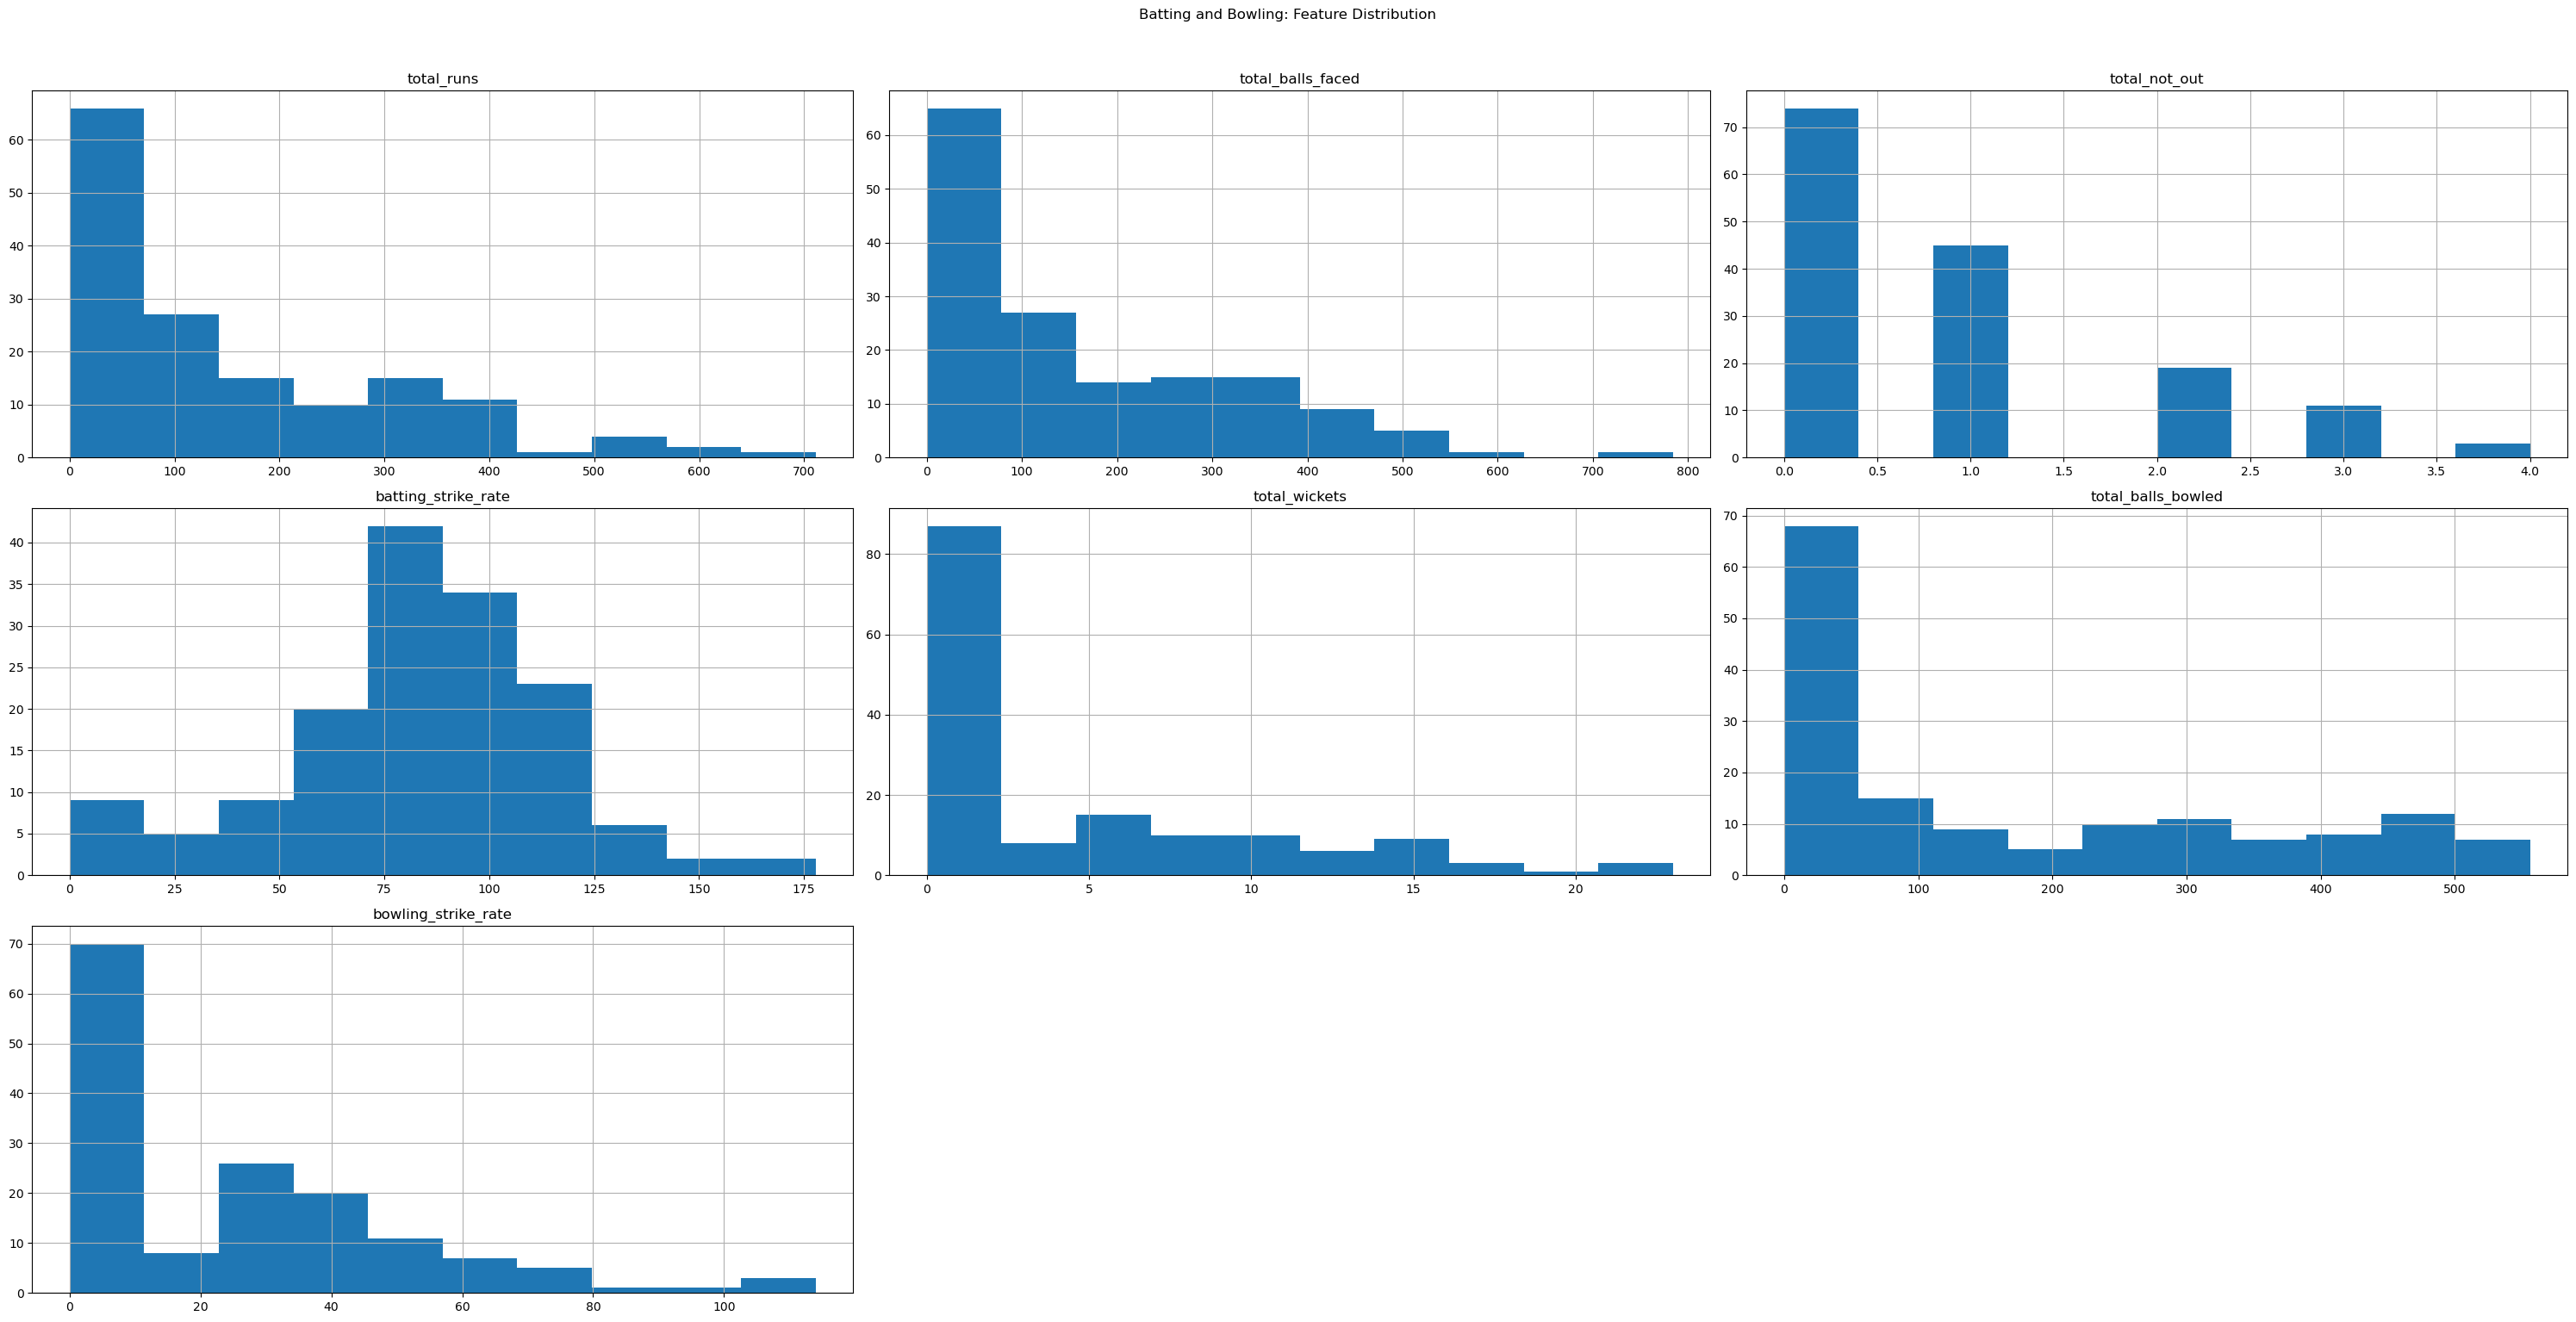

In [43]:
# Analyzing Individual player statistics
player_statistics.drop(columns = ["player"]).hist(figsize = (30, 15))
plt.suptitle('Batting and Bowling: Feature Distribution', x = 0.5, y = 1.02, ha = 'center', fontsize = 'large')
plt.tight_layout()
plt.show()

Most of the distribution is skewed to the left, except the "batting_strike_rate" metrics which is skewed.

A high number of players scored less runs, took less number of wickets, have a less number of balls bowled and faced and a less bowling strike rate.

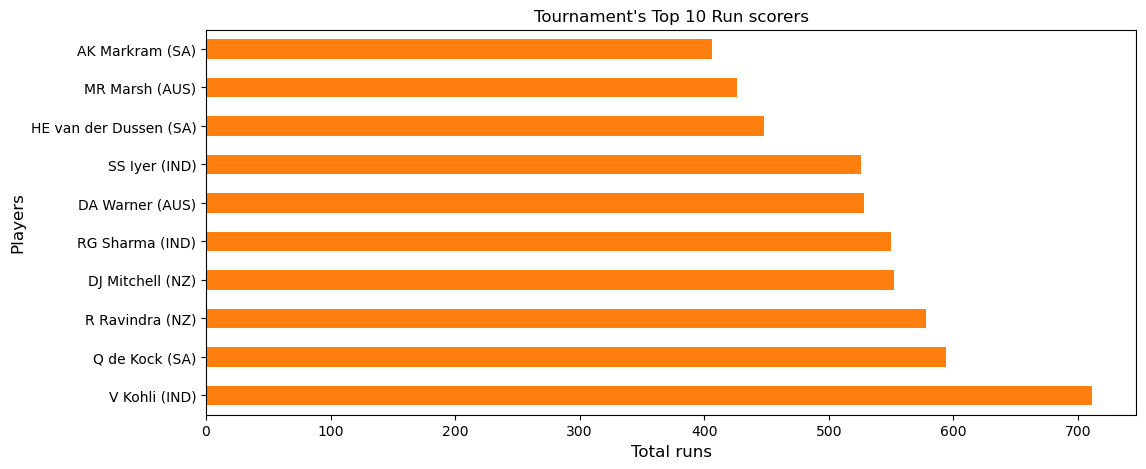

In [45]:
# Identifying leading run scorers and wicket takers
# Displaying the top run scorers of the tournament
player_statistics.groupby('player')['total_runs'].sum().sort_values(ascending = False).head(10).plot(
                    kind = 'barh',
                    figsize = [12, 5],
                    color = "C1"
)
plt.xlabel("Total runs", fontsize = 12)
plt.ylabel("Players", fontsize = 12)
plt.title("Tournament's Top 10 Run scorers", fontsize = 12)
plt.show()

The leading run scorer of the World Cup 2023 tournament was "V Kohli" from "IND" with a total run score of more than 700. Second by "Q de Kock" from "SA" and third by "R Ravindra" from "NZ".

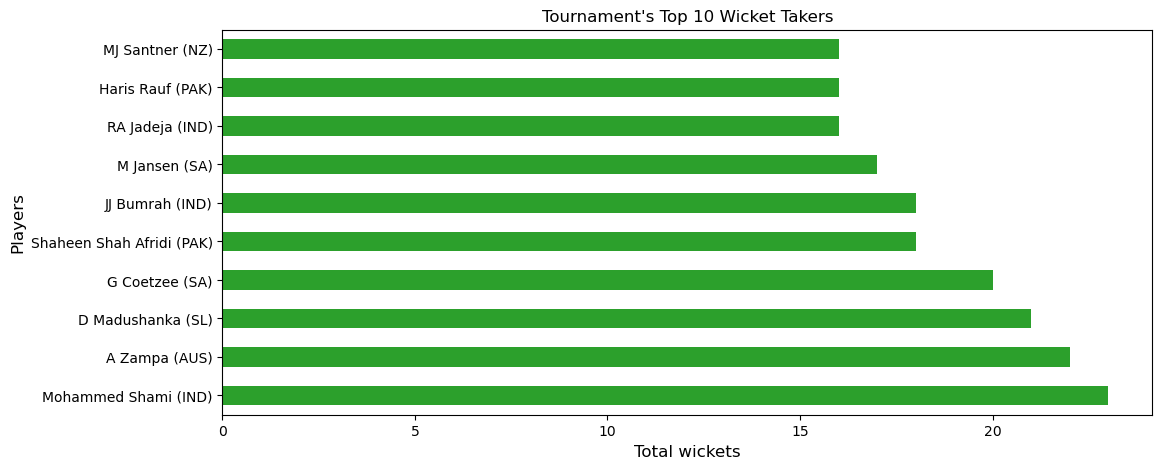

In [47]:
# Displaying the top wicket takers of the tournament
player_statistics.groupby('player')['total_wickets'].sum().sort_values(ascending = False).head(10).plot(
                    kind = 'barh',
                    figsize = [12, 5],
                    color = "C2"
)
plt.xlabel("Total wickets", fontsize = 12)
plt.ylabel("Players", fontsize = 12)
plt.title("Tournament's Top 10 Wicket Takers", fontsize = 12)
plt.show()

The leading wicket takers of the World Cup 2023 tournament was "Mohammed Shami" from "IND" with a total number of wicket greater than 20. Second by "A Zampa" from "AUS" and third by "D Madushanka" from "SL".

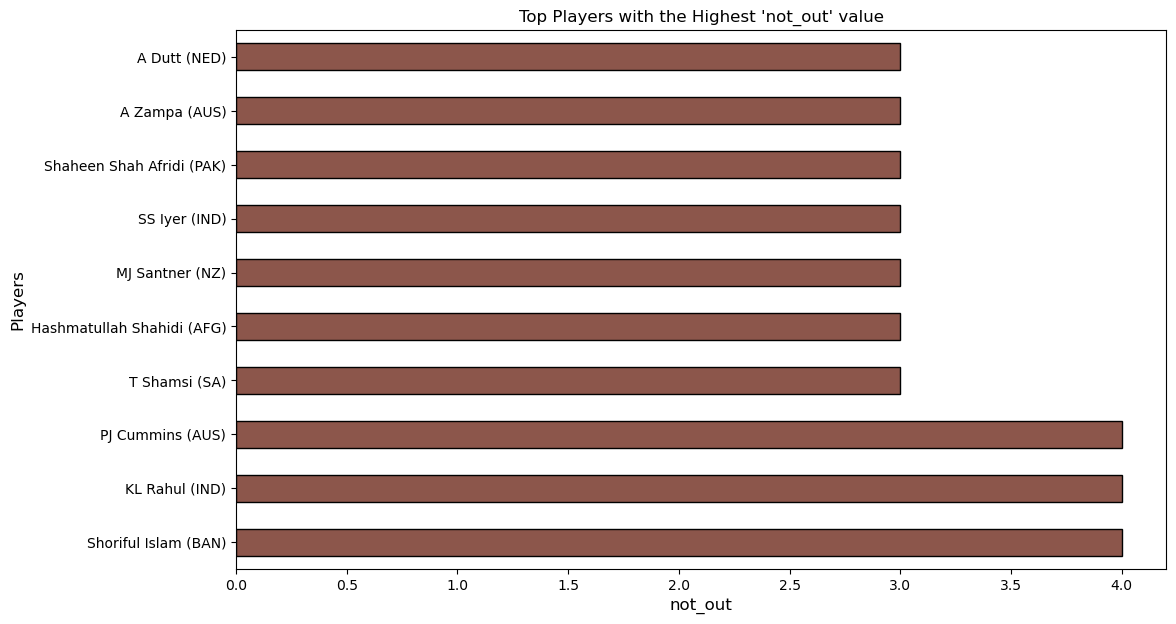

In [49]:
# # Displaying players with the highest 'not_out'
player_statistics.groupby('player')['total_not_out'].sum().sort_values(ascending = False).head(10).plot(
                    kind = 'barh',
                    figsize = [12, 7],
                    color = "C5", 
                    edgecolor = 'black'
)
plt.xlabel("not_out", fontsize = 12)
plt.ylabel("Players", fontsize = 12)
plt.title("Top Players with the Highest 'not_out' value", fontsize = 12)
plt.show()

The above chart displays players specifically batsmen and the number of times they weren't dismissed from the game.  

We want to continue analysis on the player's performance by assessing the impact of players on their team's performance. In order to do so, we will determine the batting contribution *(number of runs)* and bowling contribution *(number of wickets)* in percentage of each player on their team's performance.

In [52]:
def players_impact(team_summary_bat, team_summary_bowl, player_statistics):
    """
    Assessing the impact of players on their team's performance by calculating the percentage contribution
    """
    # Retrieving Team's statistics data from the batting and bowling metrics
    team_batting_stat = team_summary_bat[['team', 'total_runs']]
    team_bowling_stat = team_summary_bowl[['team', 'total_wickets']]
    
    # Merging these two tables on the 'team' column
    team_stat = pd.merge(team_batting_stat, team_bowling_stat, on = 'team', how = 'inner').copy()
    
    # Selecting only the necessary columns from the player_statistics
    player_stat = player_statistics[['player', 'total_runs', 'total_wickets']].copy()
    
    """
    Creating a column 'team' for the player_stat DataFrame in order to merge the team_stat with the player_stat on team column
    """
    player_stat["team"] = player_stat["player"].str.split("(").str[-1].str.replace(")", "")
    
    # Merging the player stat with team stat on 'team' column
    impact_df = pd.merge(player_stat, team_stat, on = 'team', how = 'left', suffixes = ('_player', '_team'))
    
    # Calculating Batting Contribution percentage
    impact_df['Batting_Contribution (%)'] = (impact_df['total_runs_player'] / impact_df['total_runs_team'].replace({0: np.nan})) * 100
    
    # Calculating Bowling Contribution percentage
    impact_df['Bowling_Contribution (%)'] = (impact_df['total_wickets_player'] / impact_df['total_wickets_team'].replace({0: np.nan})) * 100
    
    return impact_df

if __name__ == '__main__':
    print("-" * 100)

    # Assess Player Impact 
    player_impact_summary = players_impact(team_summary_bat, team_summary_bowl, player_statistics)
    print("Player Impact Assessment (Percentage Contribution to Team):")

player_impact_summary

----------------------------------------------------------------------------------------------------
Player Impact Assessment (Percentage Contribution to Team):


,player,total_runs_player,total_wickets_player,team,total_runs_team,total_wickets_team,Batting_Contribution (%),Bowling_Contribution (%)
0,A Dutt (NED),70.0,10.0,NED,1728,63.0,4.050926,15.873016
1,A Zampa (AUS),48.0,22.0,AUS,2722,77.0,1.763409,28.571429
2,AAP Atkinson (ENG),37.0,4.0,ENG,2135,65.0,1.733021,6.153846
3,AD Mathews (SL),51.0,6.0,SL,1942,50.0,2.626159,12.000000
4,AK Markram (SA),406.0,1.0,SA,2773,88.0,14.641183,1.136364
...,...,...,...,...,...,...,...,...
147,Usama Mir (PAK),0.0,4.0,PAK,2220,65.0,0.000000,6.153846
148,V Kohli (IND),711.0,1.0,IND,2810,94.0,25.302491,1.063830
149,Vikramjit Singh (NED),98.0,0.0,NED,1728,63.0,5.671296,0.000000
150,W Barresi (NED),83.0,0.0,NED,1728,63.0,4.803241,0.000000


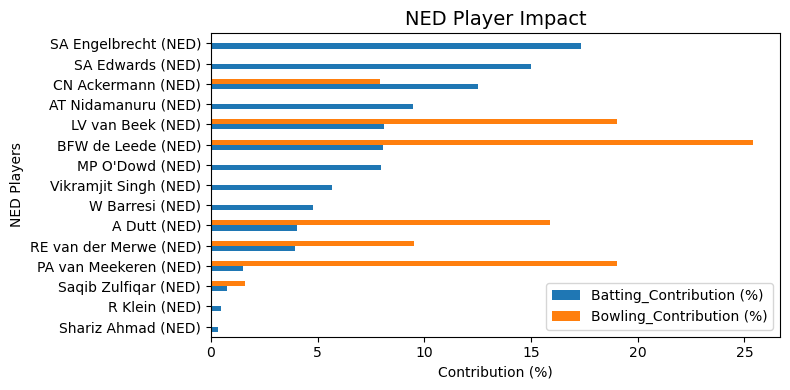

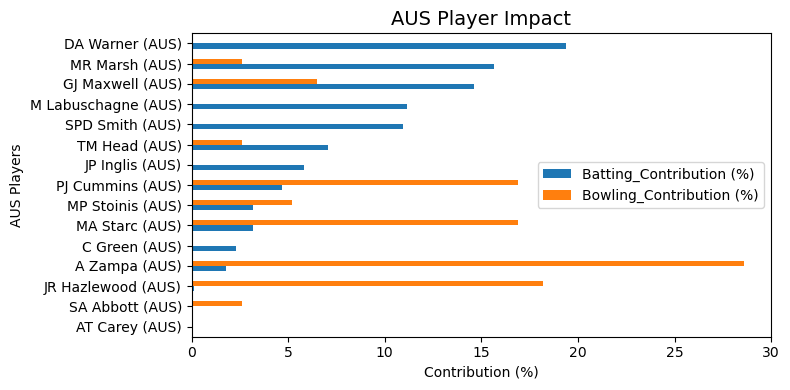

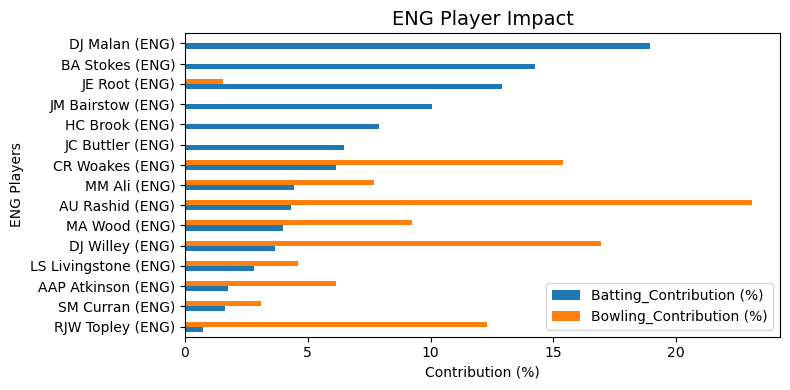

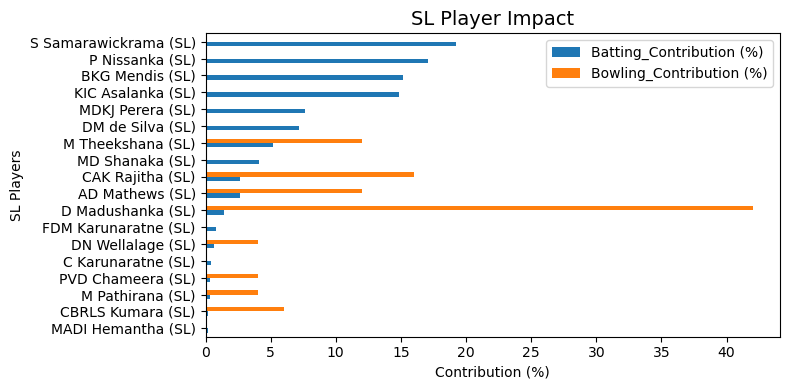

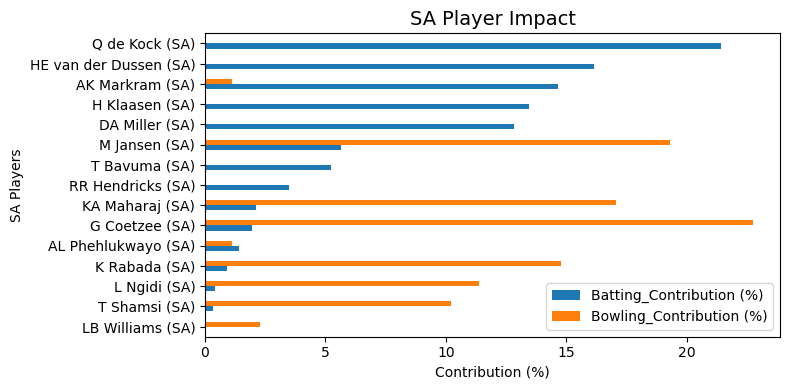

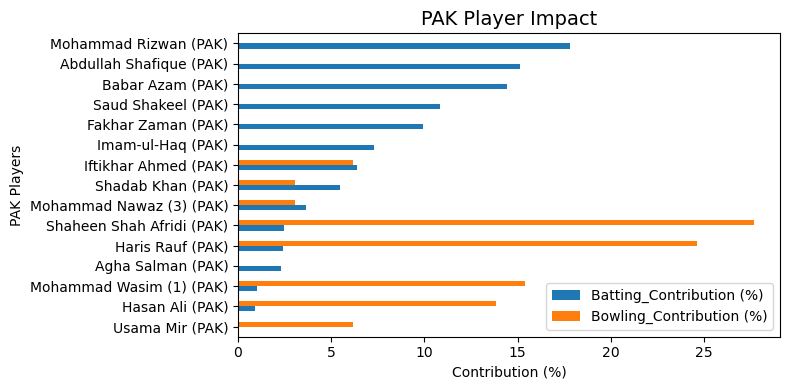

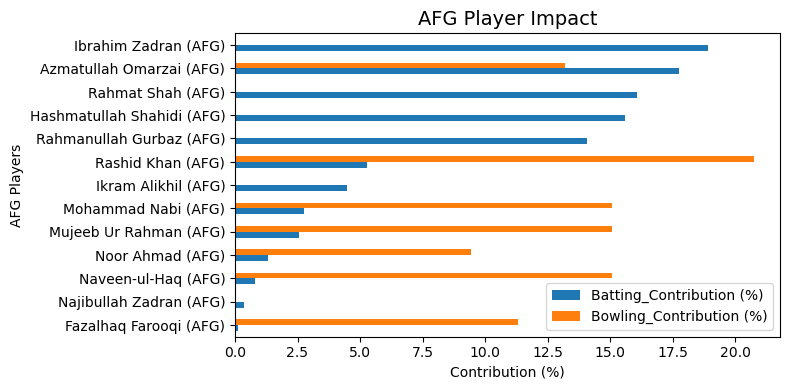

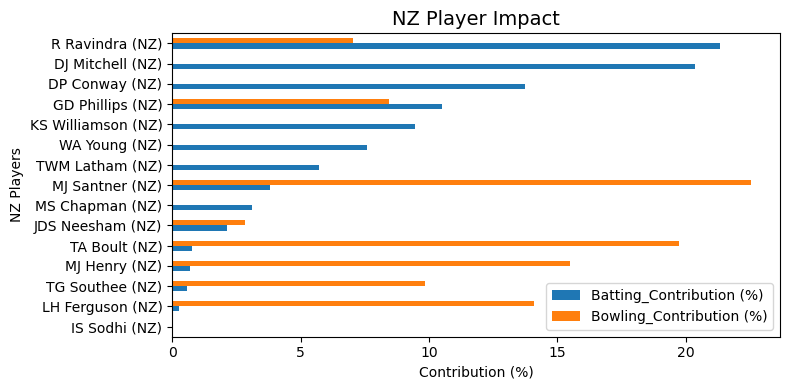

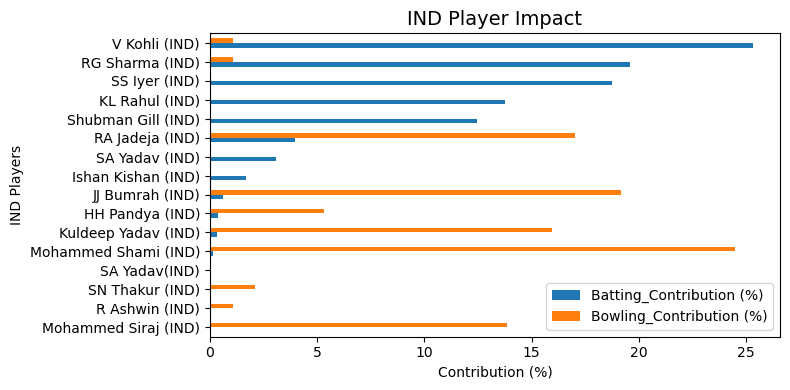

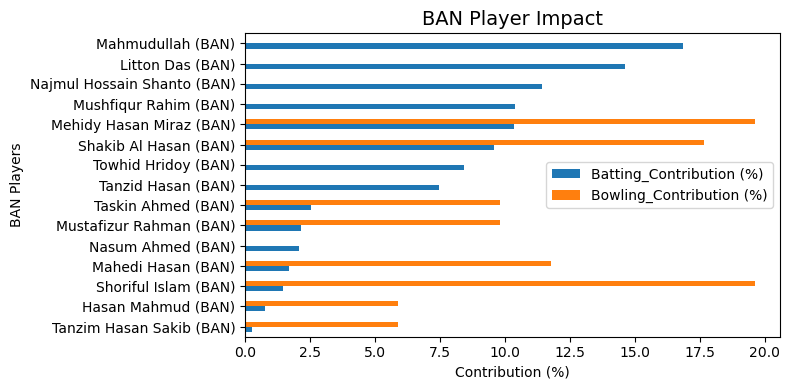

In [53]:
# Assessing the impact of the players on the team's performances
teams = list(player_impact_summary.team.unique())

for team in teams:
    # Filter for this team
    team_data = player_impact_summary[player_impact_summary["team"] == team]
    
    # Group by player and sum contributions
    player_impact = team_data.groupby("player")[["Batting_Contribution (%)", "Bowling_Contribution (%)"]].sum().sort_values(by = "Batting_Contribution (%)")
    
    # Plot horizontal bar chart
    player_impact.plot(kind="barh", figsize=(8, 4))
    plt.xlabel("Contribution (%)")
    plt.ylabel(f"{team} Players")
    plt.title(f"{team} Player Impact", fontsize = 14)
    plt.tight_layout()
    plt.show()

From the above visualization, we can discover that:
- Players of the teams that participated in the tournament contributed not more than 23% of their team's total runs, except for the team "IND" with just a player that contributed more than 25% **("V Kohli")** of the team's total run.
- There are six teams with players that contributed less than 25% of the wickets taken and the rest of the teams, that is "NED", "AUS", "SL", and "PAK" have just a single player with a contribution value of more than 25%.
- The team "SL" has a player **(D. Madushanka)** with the greatest bowling contribution of around 42% compared with any other player that participated during the tournament. This means that this player has a huge impact on the team's performance (i.e total wickets taken).

#### 3. Opposition and Ground Analysis

We will begin this analysis by investigating how teams and players performed against different oppositions.

In [57]:
def analyze_team_vs_opposition(wc_df):
    """
    Analyzes team performance metrics specifically against each opposition team.
    Requires the 'Opposition' column to be present.
    """
        
    # Group by both team and the opposition to see performance in each matchup
    team_vs_opp_performance = wc_df.groupby(['team', 'opposition']).agg(
        total_runs = ('runs', 'sum'),
        total_wickets = ('wkts', 'sum'),
        total_not_out = ('not_out', 'sum'),
        avg_strike_rate = ('sr', 'mean'),
        avg_econ = ('econ', 'mean')
    ).reset_index()

    return team_vs_opp_performance
if __name__ == '__main__':
    team_vs_opp_summary = analyze_team_vs_opposition(wc_df)
    print("Team Performance Against Specific Opposition:")
    print("-" * 100)
    print(team_vs_opp_summary)

Team Performance Against Specific Opposition:
----------------------------------------------------------------------------------------------------
   team    opposition  total_runs  total_wickets  total_not_out  \
0   AFG     Australia         563            6.0            2.0   
1   AFG    Bangladesh         303            3.0            0.0   
2   AFG       England         480           10.0            1.0   
3   AFG         India         525            2.0            2.0   
4   AFG   Netherlands         346            6.0            1.0   
..  ...           ...         ...            ...            ...   
86   SL         India         391            6.0            1.0   
87   SL   Netherlands         495            9.0            2.0   
88   SL   New Zealand         339            4.0            1.0   
89   SL      Pakistan         675            4.0            1.0   
90   SL  South Africa         733            5.0            1.0   

    avg_strike_rate  avg_econ  
0         56.884

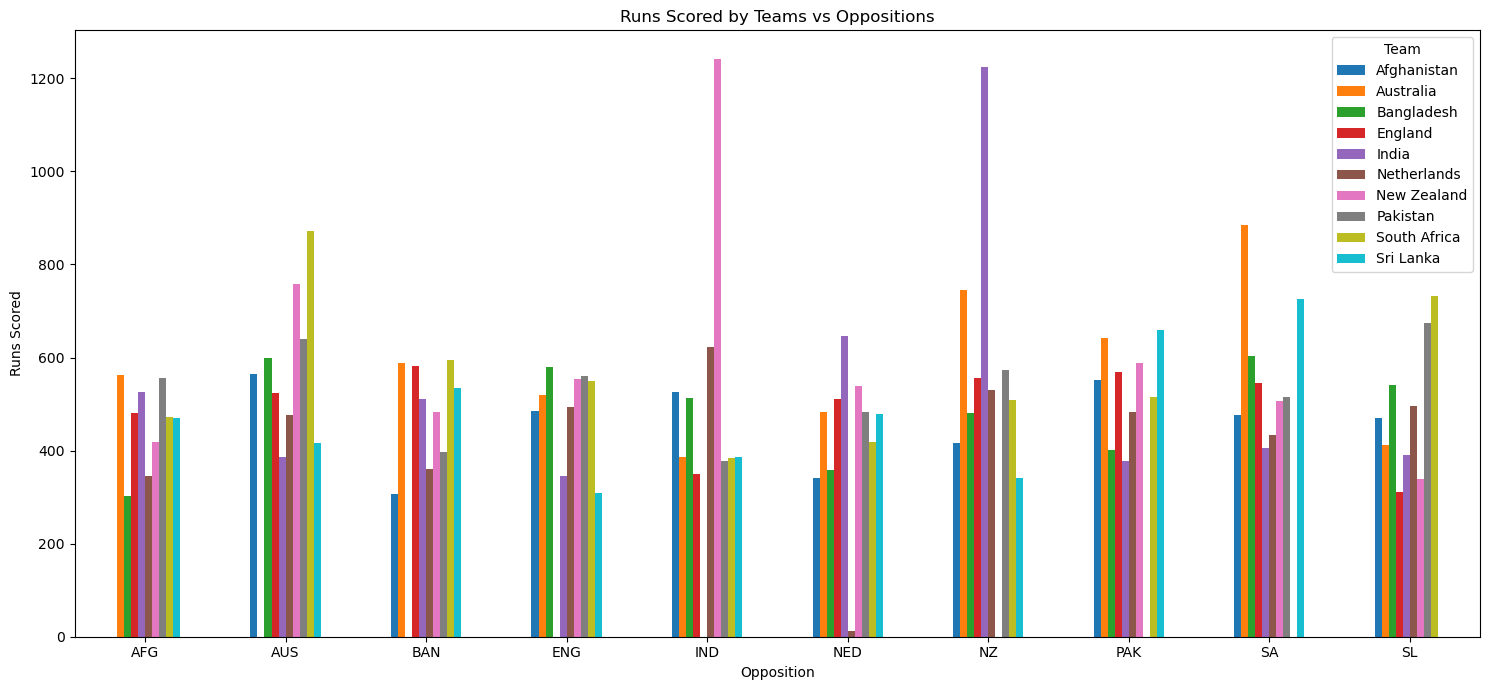

In [58]:
# Creating a Grouped Bar chart to analyze the run performance of teams against opposition teams
# Step 1: Pivot so teams are columns and oppositions are index
# -------------------------
pivot_df = team_vs_opp_summary.pivot(index = "team", columns = "opposition", values = "total_runs")

# -------------------------
# Step 2: Plot Bar chart
# -------------------------
pivot_df.plot(kind = "bar", figsize = (15, 7))

plt.title("Runs Scored by Teams vs Oppositions")
plt.xlabel("Opposition")
plt.ylabel("Runs Scored")
plt.legend(title = "Team")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

The above visualization gives us an illustration on the performance of teams against each opposition teams by the number of runs scored. From the chart, we can observe that:
- The "AFG", "BAN" and "ENG" team scored a maximum number of runs less than 600 against each opposition team.
- The "IND" and "NZ" team scored a maximum number of runs far greater than 1000 against each other.

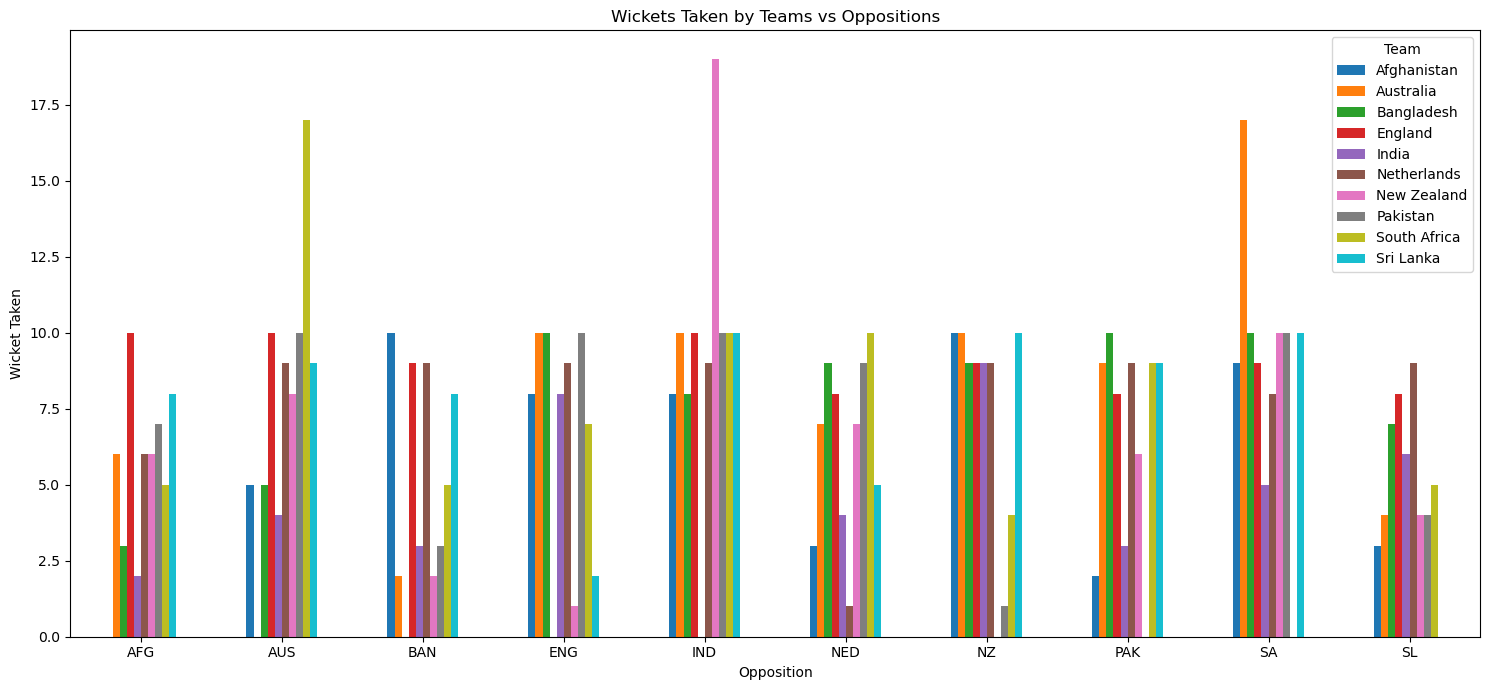

In [60]:
# Creating a Grouped Bar chart to analyze the wicket performance of teams against opposition teams
# -------------------------
pivot_df = team_vs_opp_summary.pivot(index = "team", columns = "opposition", values = "total_wickets")

# -------------------------
# Plot Bar chart
# -------------------------
pivot_df.plot(kind = "bar", figsize = (15, 7))

plt.title("Wickets Taken by Teams vs Oppositions")
plt.xlabel("Opposition")
plt.ylabel("Wicket Taken")
plt.legend(title = "Team")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

The above visualization gives us an illustration on the performance of teams against each opposition teams by the number of wickets taken. From the chart, we can observe that:
- Among all the teams, "AUS", "IND" and "SA" team have maximum wicket value far greater than 10 against each opposition team compared to the maximum wicket value of the rest of the teams (which is equal to 10).

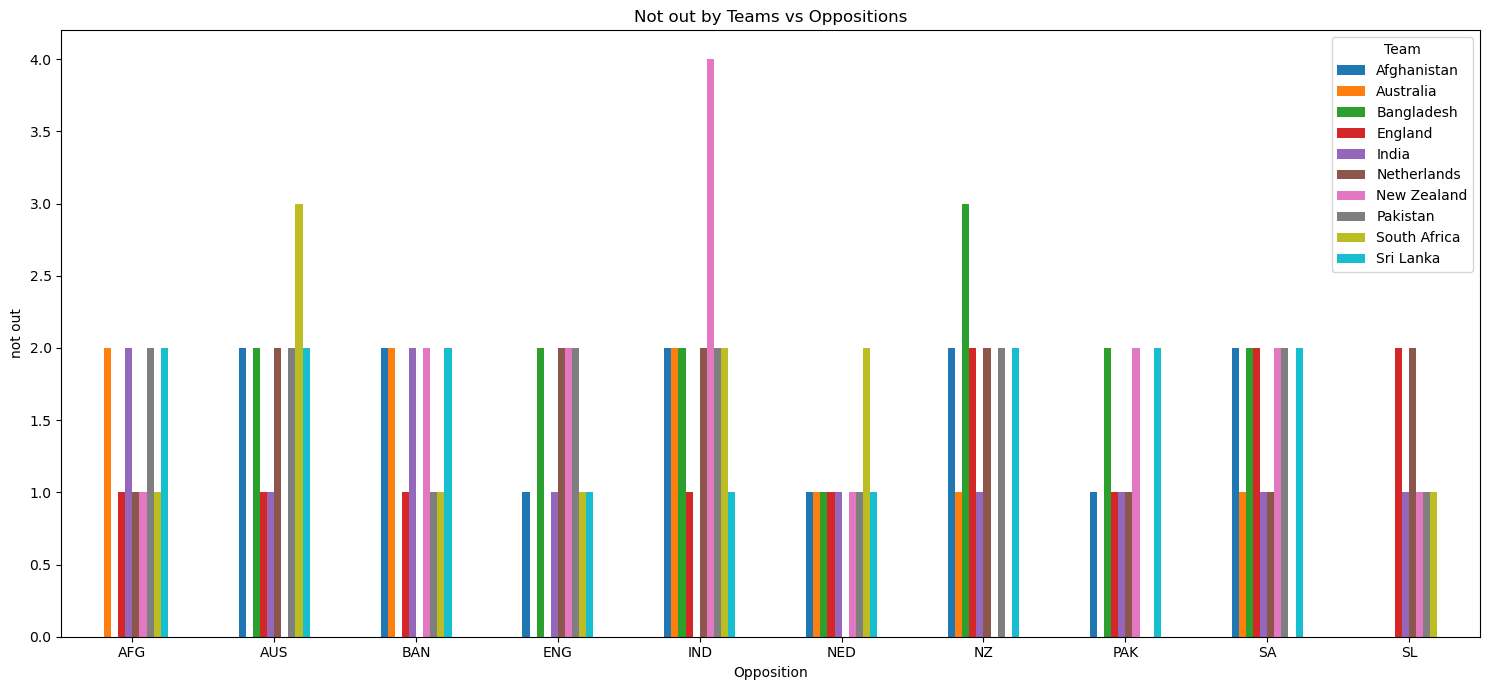

In [62]:
# Creating a Grouped Bar chart to analyze the 'not_out' performance of teams against opposition teams
# -------------------------
pivot_df = team_vs_opp_summary.pivot(index = "team", columns = "opposition", values = "total_not_out")

# -------------------------
# Plot Bar chart
# -------------------------
pivot_df.plot(kind = "bar", figsize = (15, 7))

plt.title("Not out by Teams vs Oppositions")
plt.xlabel("Opposition")
plt.ylabel("not out")
plt.legend(title = "Team")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

From the above chart, we can observe team 'IND' has the maximum not out value of 4 when playing against New Zealand which therefore means that it's players have not been dismissed in 4 matches or in 4 innings.  

In [64]:
def analyze_player_vs_opposition(wc_df):
    """
    Analyzes individual player performance metrics specifically against each opposition team.
    Requires the 'Opposition' column to be present.
    """
    
    # Group by player, team, AND opposition
    player_vs_opp_batting = wc_df.groupby(['player', 'team', 'opposition']).agg(
        total_runs = ('runs', 'sum'),
        total_wicket = ('wkts', 'sum'),
        total_strike_rate = ('sr', 'mean'),
        avg_econ = ('econ', 'mean'),
        total_mins = ('mins', 'sum')
    ).reset_index()
    
    return player_vs_opp_batting

if __name__ == '__main__':
    print("-" * 100)
    player_vs_opp_summary = analyze_player_vs_opposition(wc_df)
    print("Player Batting Performance Against Specific Opposition:")
    print(player_vs_opp_summary)

----------------------------------------------------------------------------------------------------
Player Batting Performance Against Specific Opposition:
            player team    opposition  total_runs  total_wicket  \
0     A Dutt (NED)  NED   Afghanistan          59           0.0   
1     A Dutt (NED)  NED     Australia          60           1.0   
2     A Dutt (NED)  NED    Bangladesh          35           1.0   
3     A Dutt (NED)  NED       England          68           2.0   
4     A Dutt (NED)  NED         India          57           0.0   
..             ...  ...           ...         ...           ...   
974  WA Young (NZ)   NZ     Australia          32           0.0   
975  WA Young (NZ)   NZ       England           0           0.0   
976  WA Young (NZ)   NZ         India          17           0.0   
977  WA Young (NZ)   NZ   Netherlands          70           0.0   
978  WA Young (NZ)   NZ  South Africa          33           0.0   

     total_strike_rate  avg_econ  tota

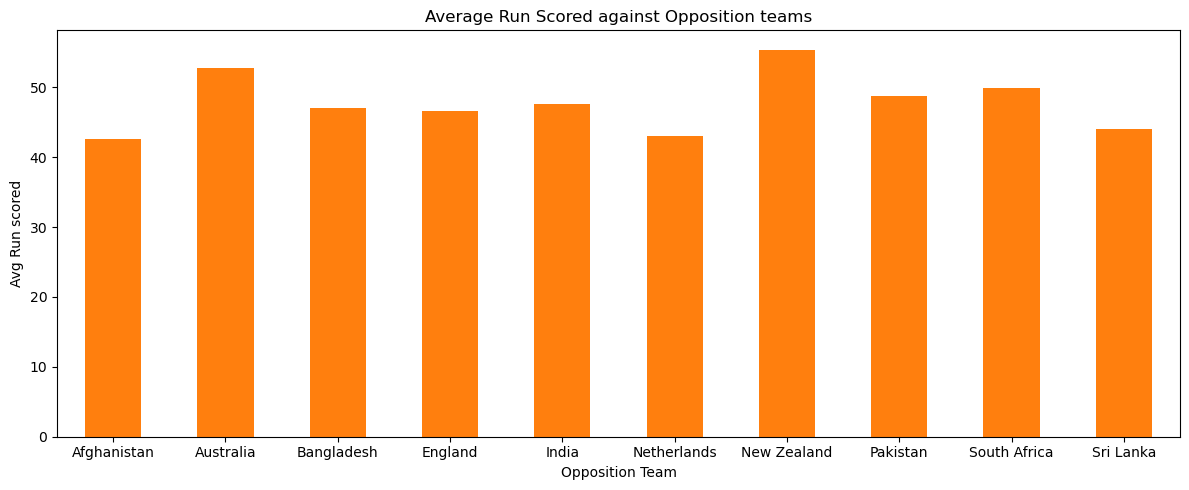

In [65]:
# Average runs scored against each opponent team
avg_runs_scored = player_vs_opp_summary.groupby('opposition')['total_runs'].mean().round(2)
avg_runs_scored.plot(kind = 'bar', figsize = (12, 5), color = 'C1')
plt.xlabel('Opposition Team')
plt.ylabel('Avg Run scored')
plt.title('Average Run Scored against Opposition teams')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Our next task is to examine the performance variation of teams across different playing grounds.

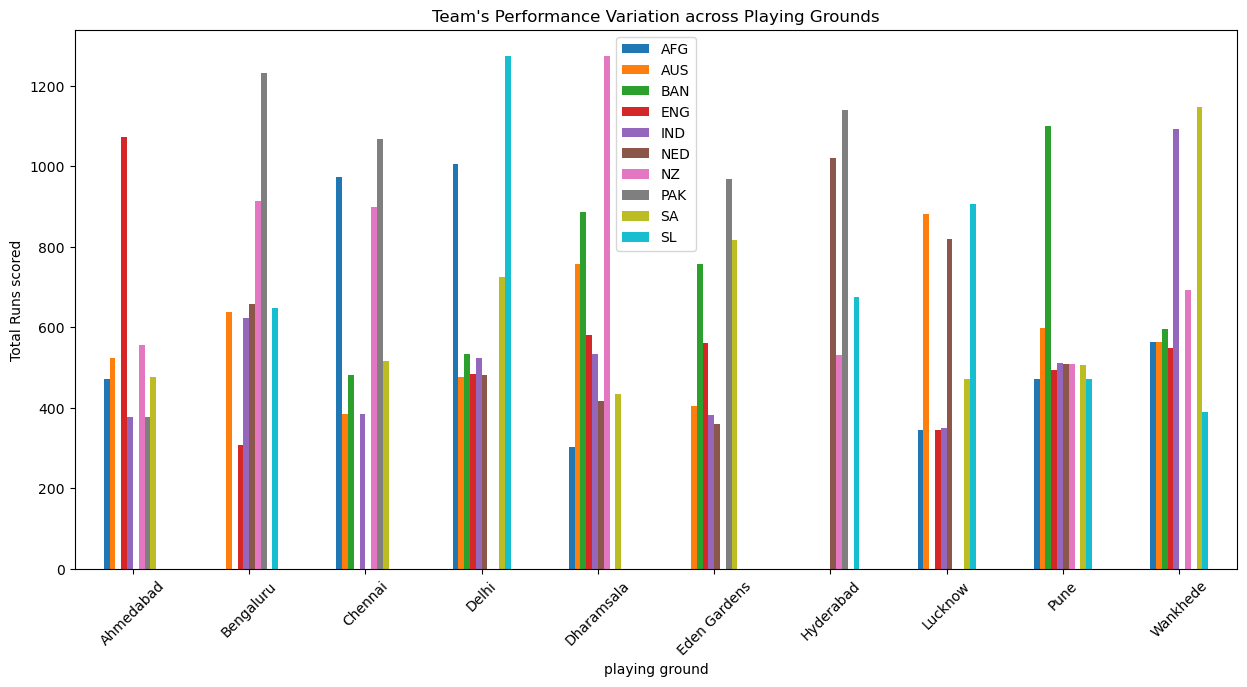

In [67]:
# Examining the performance variation of teams across different playing grounds
team_vs_ground_performance = wc_df.groupby(['team', 'ground']).agg(
        total_runs = ('runs', 'sum'),
        total_wickets_taken = ('wkts', 'sum'),
        # Calculate the mean economy rate only for the innings where bowling occurred (economy_rate > 0)
        avg_economy_rate=('econ', lambda x: x[x > 0].mean()), 
    ).reset_index()


pivot_data = team_vs_ground_performance.pivot(index = 'ground', columns = 'team', values = 'total_runs')
pivot_data.plot(kind = 'bar', figsize = (15, 7))
plt.xlabel('playing ground')
plt.ylabel('Total Runs scored')
plt.title("Team's Performance Variation across Playing Grounds")
plt.xticks(rotation = 45)
plt.legend()
plt.show()

#### 4. Temporal Analysis

For this analysis, we want to study the performance trends of players and teams over time by considering the 'start_date' columns and other metrics.

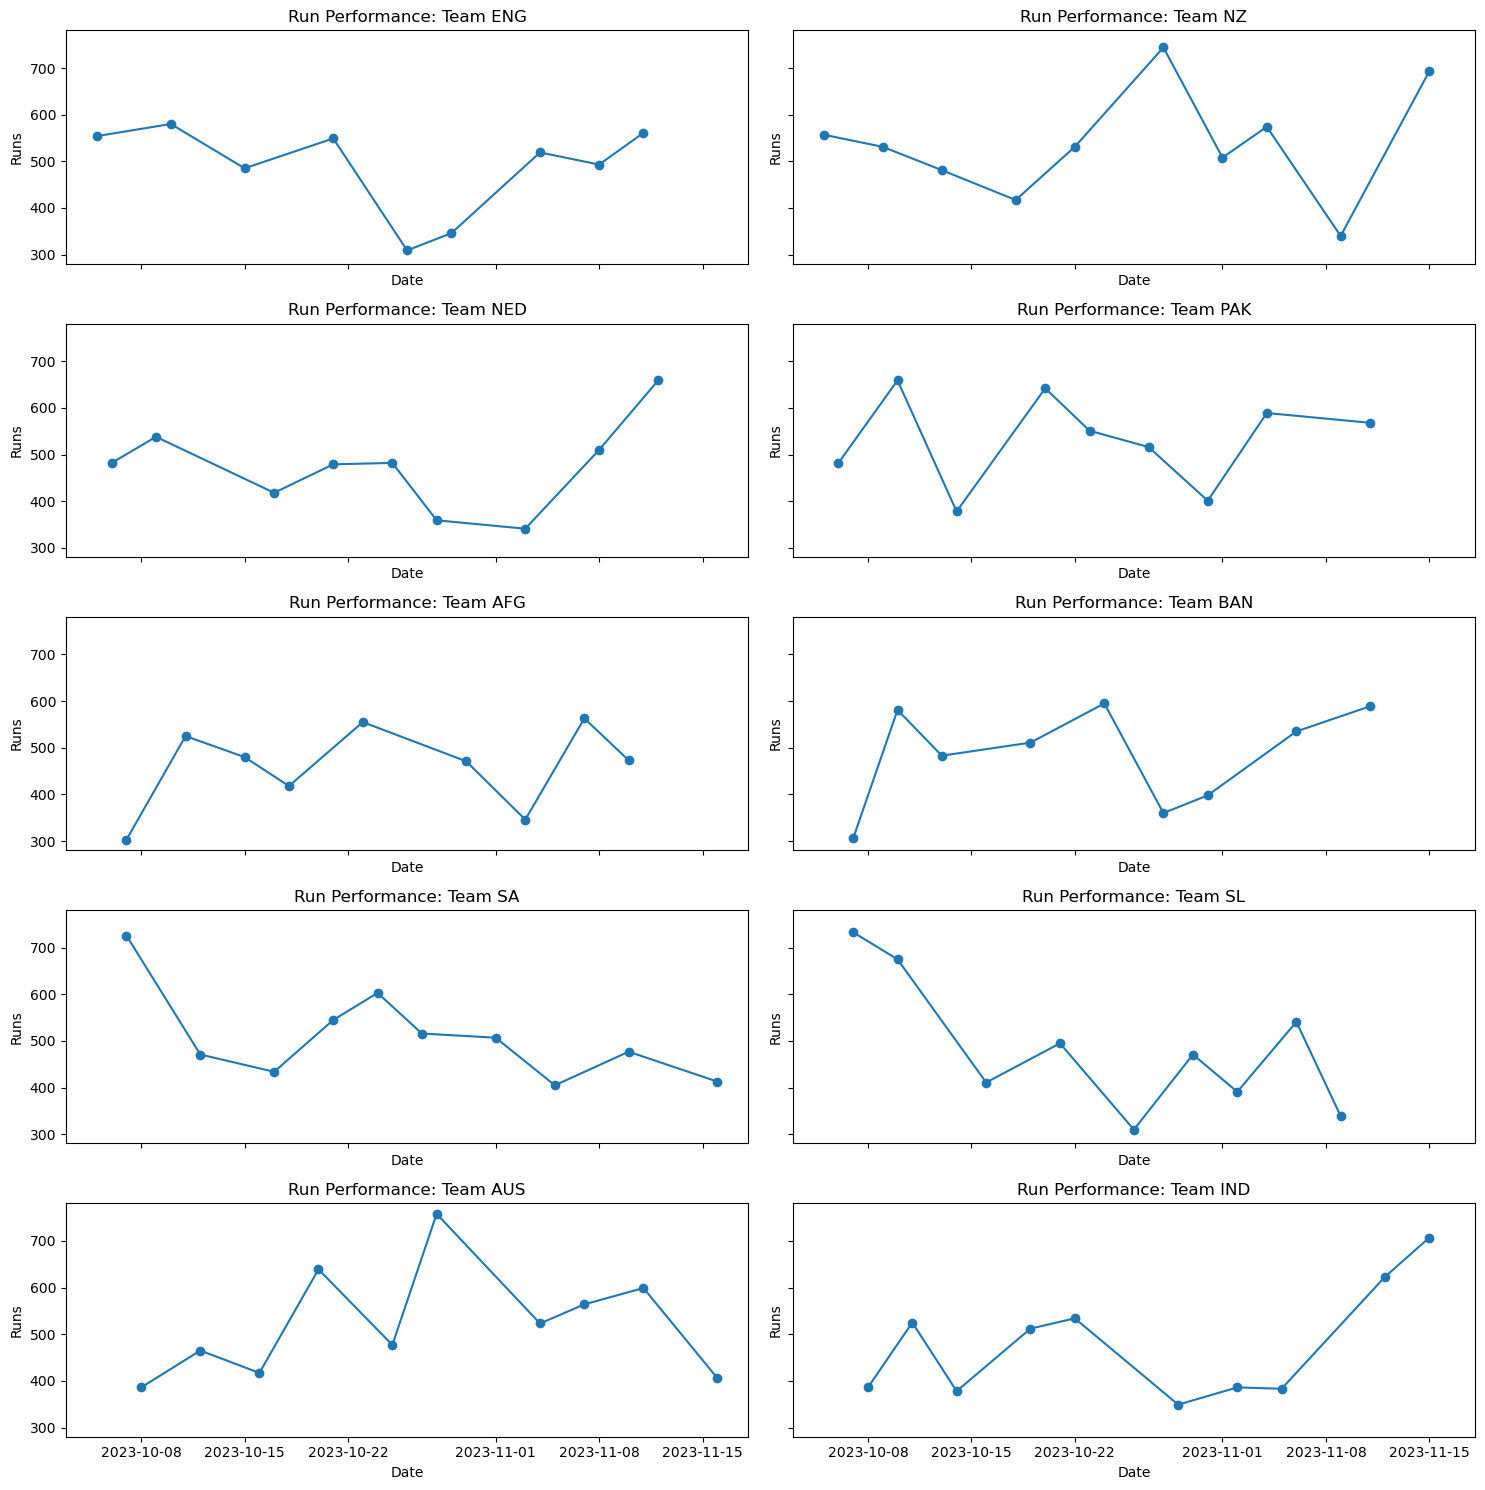

In [70]:
# Analyzing team performance trend over time by total runs
time_series_performance = wc_df.groupby(['start_date', 'team']).agg(
        total_runs = ('runs', 'sum'),
        total_overs = ('overs', 'sum'),
        total_wickets = ('wkts', 'sum')
    ).reset_index()

# Creating a line plot
teams = time_series_performance["team"].unique()

fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (15,15), sharex = True, sharey = True)

axes = axes.flatten()  # make it 1D

for i, team in enumerate(teams):
    ax = axes[i]
    team_data = time_series_performance[time_series_performance["team"] == team]
    ax.plot(team_data["start_date"], team_data["total_runs"], marker = "o")
    ax.set_title(f"Run Performance: Team {team}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Runs")

plt.tight_layout()
plt.show()

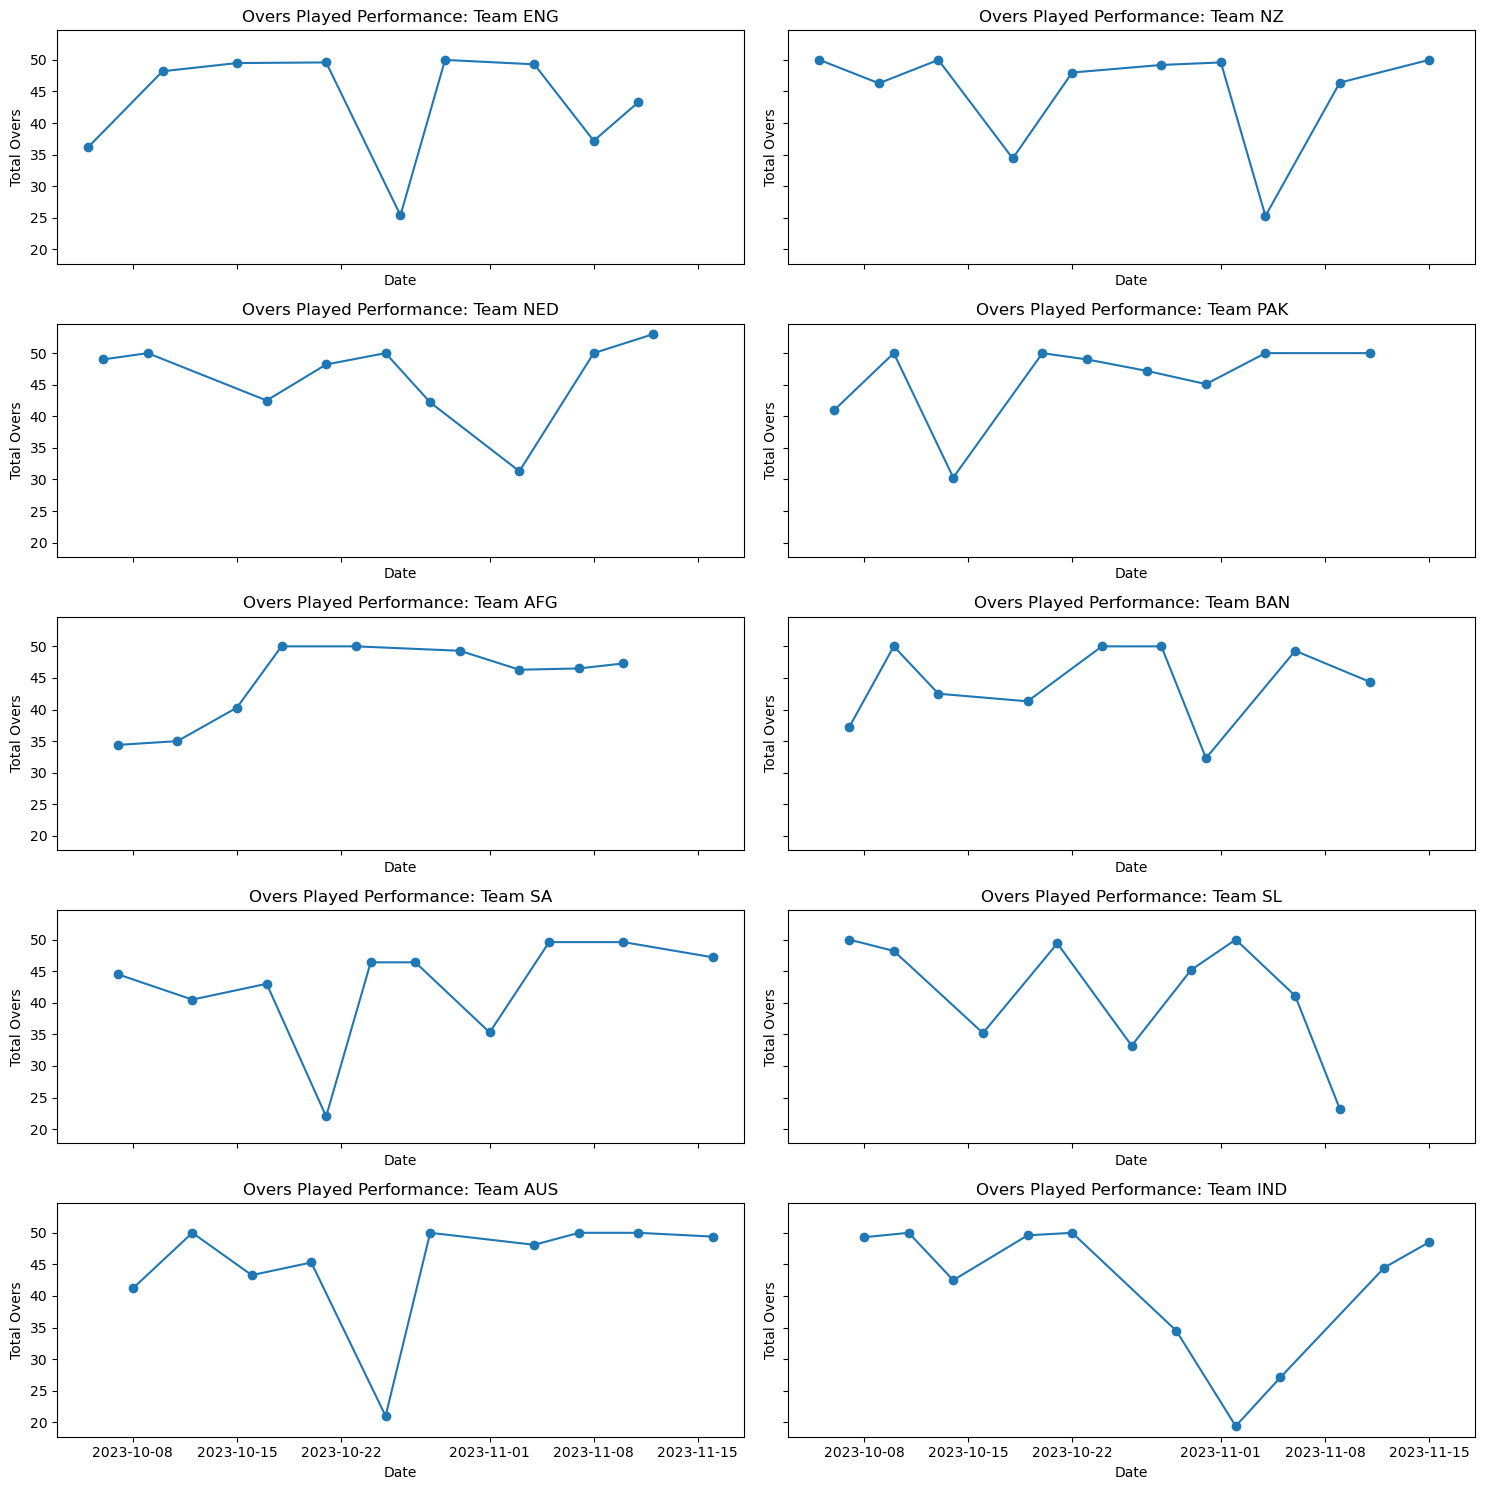

In [112]:
# Analyzing team's performance trend over time by overs
time_series_performance = wc_df.groupby(['start_date', 'team']).agg(
        total_runs = ('runs', 'sum'),
        total_overs = ('overs', 'sum'),
        total_wickets = ('wkts', 'sum')
    ).reset_index()

# Creating a line plot
teams = time_series_performance["team"].unique()

fig, axes = plt.subplots(nrows = 5, ncols = 2, figsize = (15,15), sharex = True, sharey = True)

axes = axes.flatten()  # make it 1D

for i, team in enumerate(teams):
    ax = axes[i]
    team_data = time_series_performance[time_series_performance["team"] == team]
    ax.plot(team_data["start_date"], team_data["total_overs"], marker = "o")
    ax.set_title(f"Overs Played Performance: Team {team}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total Overs")

plt.tight_layout()
plt.show()